In [1]:
import xarray as xr
import cfgrib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ds_fc = xr.open_dataset('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/6/ifs_fc_2t_0000_6_20160101.grib', engine="cfgrib")
ds_an = xr.open_dataset('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/an/0.125/2t/ifs_an_2t_20160101.grib', engine="cfgrib")

Ignoring index file '/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/2t/0000/6/ifs_fc_2t_0000_6_20160101.grib.5b7b6.idx' older than GRIB file


/glade/work/dcalhoun/conda-envs/censuswxindex/lib/python3.13/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
Ignoring index file '/glade/derecho/scratch/dcalhoun/ecmwf/ifs/an/0.125/2t/ifs_an_2t_20160101.grib.5b7b6.idx' older than GRIB file
/glade/work/dcalhoun/conda-envs/censuswxindex/lib/python3.13/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(


In [27]:
ds_fc

<xarray.Dataset> Size: 415kB
Dimensions:     (latitude: 213, longitude: 481)
Coordinates:
    number      int64 8B ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 2kB 50.0 49.88 49.75 ... 23.75 23.62 23.5
  * longitude   (longitude) float64 4kB -125.0 -124.9 -124.8 ... -65.12 -65.0
    valid_time  datetime64[ns] 8B ...
Data variables:
    t2m         (latitude, longitude) float32 410kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-06T15:01 GRIB to CDM+CF via cfgrib-0.9.1...

In [28]:
ds_an

<xarray.Dataset> Size: 2MB
Dimensions:     (time: 4, latitude: 213, longitude: 481)
Coordinates:
    number      int64 8B ...
  * time        (time) datetime64[ns] 32B 2016-01-01 ... 2016-01-01T18:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 2kB 50.0 49.88 49.75 ... 23.75 23.62 23.5
  * longitude   (longitude) float64 4kB -125.0 -124.9 -124.8 ... -65.12 -65.0
    valid_time  (time) datetime64[ns] 32B ...
Data variables:
    t2m         (time, latitude, longitude) float32 2MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-04-06T15:01 GRIB to CDM+CF via cfgrib-0.9.1...

In [3]:
error = np.abs(ds_fc['t2m'] - ds_an.sel(time=ds_fc['valid_time'].values)['t2m'])

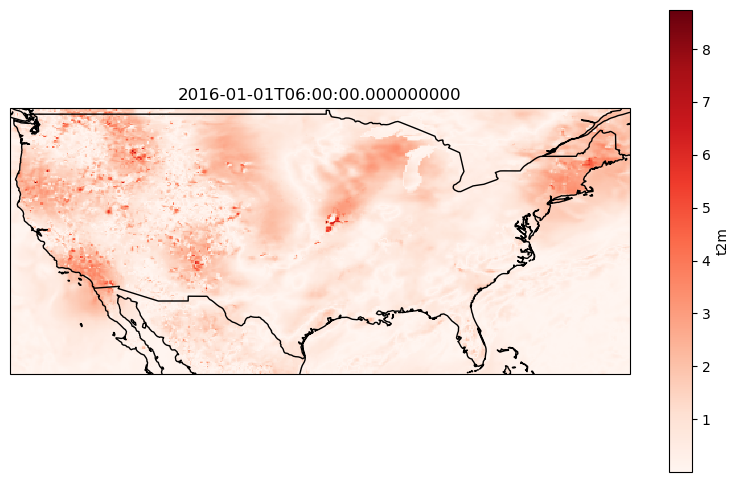

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
error.plot(ax=ax, cmap='Reds')
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)
plt.title(f'{error.valid_time.values}')
plt.show()